# FlipShop Assignment - Shubhrant Tripathi (PIET22CA052)
- Github Link - https://github.com/ishubtripathi/Flipshop-Task.git

# Introduction

This project analyzes customer behavior within an e-commerce platform using a dataset containing demographic information, purchasing behavior, engagement metrics, and satisfaction levels.

Understanding customer behavior is essential for improving customer experience, increasing retention, and optimizing marketing strategies. By analyzing patterns in spending, membership types, geographic locations, and satisfaction levels, businesses can identify high-value customers and potential churn risks.

This analysis focuses on exploring the dataset, segmenting customers based on demographics and membership type, and developing data-driven retention strategies.

# Objective

The objective of this analysis is to:

- Explore and clean the dataset to ensure data quality.

- Perform customer segmentation based on demographics, membership type, and geographic location.

- Analyze spending patterns and customer satisfaction levels across different segments.

- Identify potential churn risks based on customer purchase activity.

- Propose targeted retention strategies to improve customer engagement and loyalty.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("SampleDataSheet.csv") 
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [5]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


In [9]:
df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          0
dtype: int64

In [10]:
df = df.dropna()

In [11]:
df.duplicated().sum()

0

In [12]:
df = df.drop_duplicates()

In [14]:
df["Gender"] = df["Gender"].astype("category")
df["City"] = df["City"].astype("category")
df["Membership Type"] = df["Membership Type"].astype("category")
df["Satisfaction Level"] = df["Satisfaction Level"].astype("category")

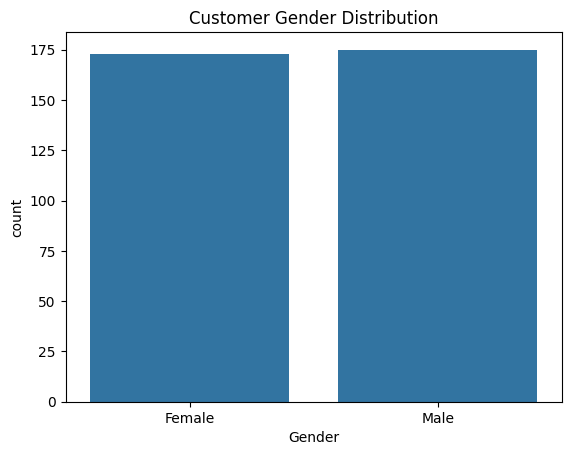

In [15]:
plt.figure()
sns.countplot(x="Gender", data=df)
plt.title("Customer Gender Distribution")
plt.show()

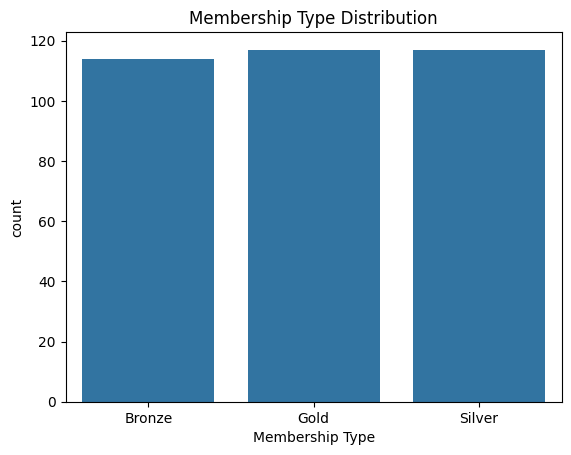

In [16]:
plt.figure()
sns.countplot(x="Membership Type", data=df)
plt.title("Membership Type Distribution")
plt.show()

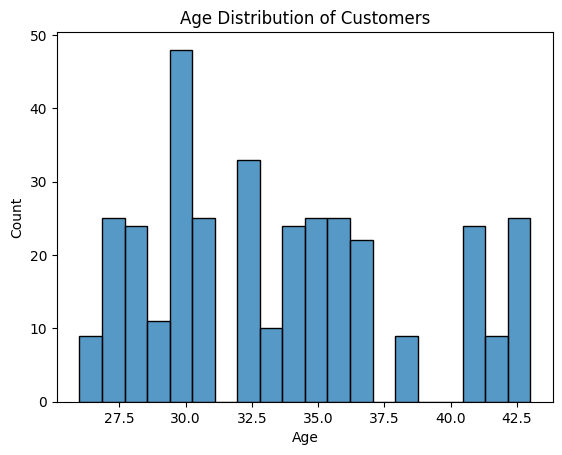

In [17]:
plt.figure()
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution of Customers")
plt.show()

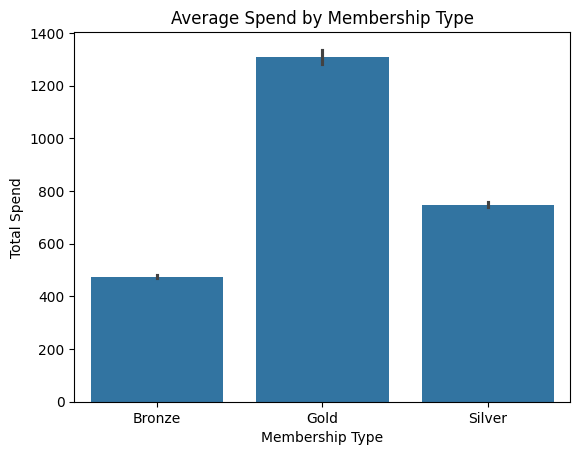

In [18]:
plt.figure()
sns.barplot(x="Membership Type", y="Total Spend", data=df)
plt.title("Average Spend by Membership Type")
plt.show()

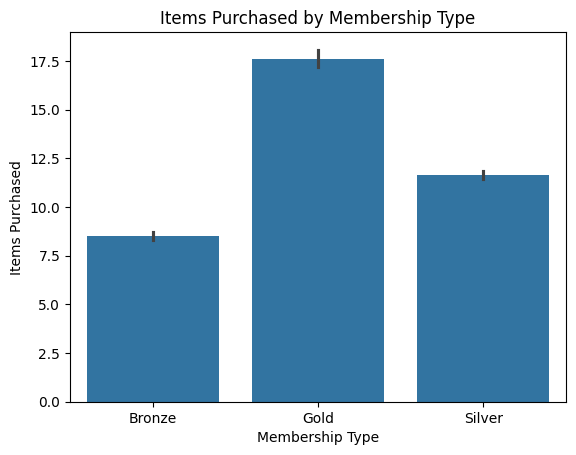

In [19]:
plt.figure()
sns.barplot(x="Membership Type", y="Items Purchased", data=df)
plt.title("Items Purchased by Membership Type")
plt.show()

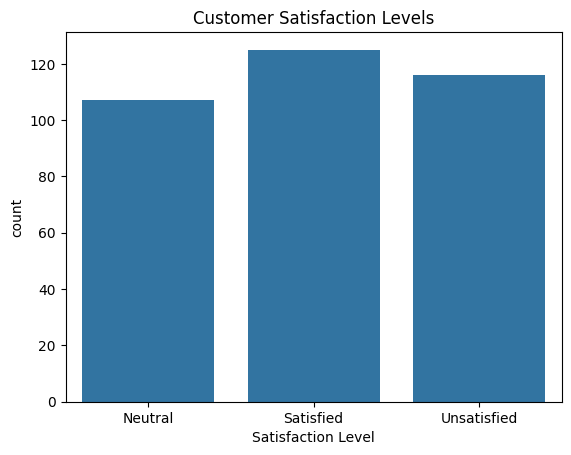

In [20]:
plt.figure()
sns.countplot(x="Satisfaction Level", data=df)
plt.title("Customer Satisfaction Levels")
plt.show()

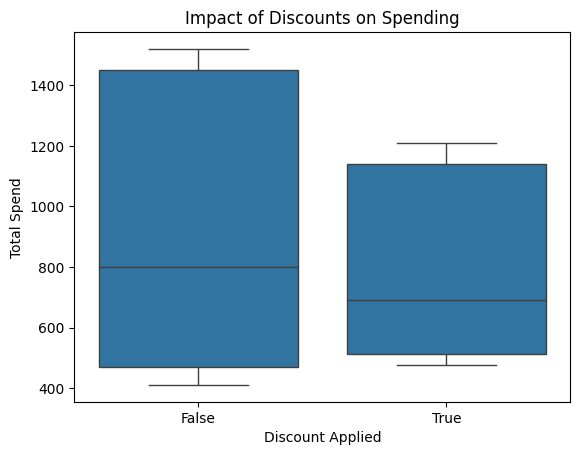

In [21]:
plt.figure()
sns.boxplot(x="Discount Applied", y="Total Spend", data=df)
plt.title("Impact of Discounts on Spending")
plt.show()

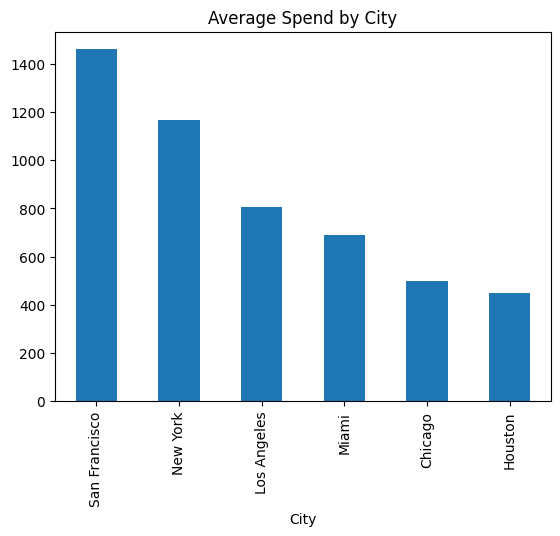

In [22]:
city_spend = df.groupby("City")["Total Spend"].mean().sort_values(ascending=False)

city_spend.plot(kind="bar")
plt.title("Average Spend by City")
plt.show()

In [23]:
def customer_status(days):
    if days <= 30:
        return "Active"
    elif days <= 90:
        return "At Risk"
    else:
        return "Churned"

df["Customer Status"] = df["Days Since Last Purchase"].apply(customer_status)

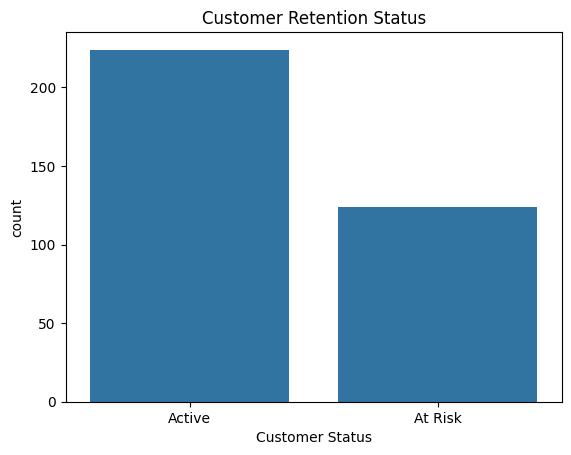

In [24]:
plt.figure()
sns.countplot(x="Customer Status", data=df)
plt.title("Customer Retention Status")
plt.show()

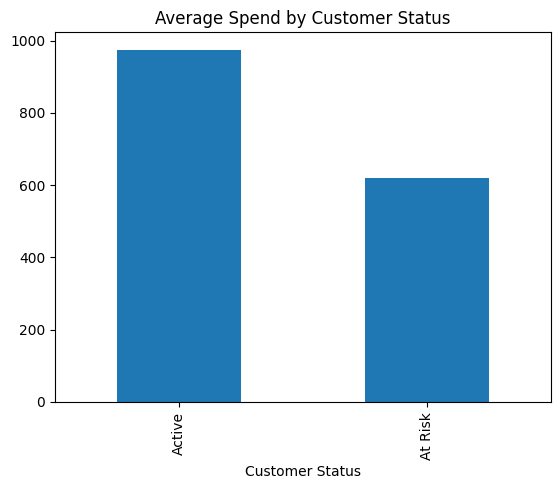

In [25]:
status_spend = df.groupby("Customer Status")["Total Spend"].mean()

status_spend.plot(kind="bar")
plt.title("Average Spend by Customer Status")
plt.show()

# FlipShop Assignment - Shubhrant Tripathi (PIET22CA052)
- Github Link - https://github.com/ishubtripathi/Flipshop-Task.git